# Анализ временных рядов

In [1]:
import pandas as pd
import numpy as np

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
COLOR = "#FF0000"

BOLD = '\033[1m'
END = '\033[0m'

import warnings
warnings.filterwarnings('ignore')

## 0. Подготовка

In [2]:
df_views = pd.read_csv('views.csv')

df_views['Date'] = pd.to_datetime(df_views['Date'], format='mixed')
df_views = df_views.sort_values(by='Date')

df_views

,Date,Video Title,External Video ID,Video Length,Thumbnail link,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
111856,2017-11-01,ProjectDemoCSC478_UFCFightData,5p73cIRYCZg,729,https://i.ytimg.com/vi/5p73cIRYCZg/hqdefault.jpg,1,0,0,0,0,0,0.003018,2.200000,0
111855,2017-11-18,Predicting Crypto-Currency Price Using RNN lST...,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,13,0,0,0,0,0,0.444176,138.138769,0
111854,2017-11-19,Predicting Crypto-Currency Price Using RNN lST...,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,4,0,0,0,0,0,0.087268,27.140250,0
111853,2017-11-20,Predicting Crypto-Currency Price Using RNN lST...,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,9,0,0,0,0,0,0.492501,153.167667,0
111852,2017-11-21,Predicting Crypto-Currency Price Using RNN lST...,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,2,0,0,0,0,0,0.693108,215.556500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,2022-01-19,What I Learned From My Three Degrees,KMOA5arCi8g,762,https://i.ytimg.com/vi/KMOA5arCi8g/hqdefault.jpg,1,0,0,0,0,0,0.098741,75.241000,0
121,2022-01-19,Sh*t Data Scientists Say (Parody),WRF_dKZ_i24,128,https://i.ytimg.com/vi/WRF_dKZ_i24/hqdefault.jpg,2,0,0,0,0,0,0.602832,77.162500,0
120,2022-01-19,How I Would Learn Data Science in 2022 (If I H...,xpIFS6jZbe8,734,https://i.ytimg.com/vi/xpIFS6jZbe8/hqdefault.jpg,1878,80,3,2,60,0,0.390613,286.710255,0
129,2022-01-19,Unboxing the Ultimate Z by HP Data Science Pac...,YR9Faf1uZDg,557,https://i.ytimg.com/vi/YR9Faf1uZDg/hqdefault.jpg,6,0,0,0,1,0,0.178014,99.154000,0


In [3]:
df_views.info()

<class 'pandas.DataFrame'>
Index: 111857 entries, 111856 to 0
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        111857 non-null  datetime64[us]
 1   Video Title                 111857 non-null  str           
 2   External Video ID           111857 non-null  str           
 3   Video Length                111857 non-null  int64         
 4   Thumbnail link              111857 non-null  str           
 5   Views                       111857 non-null  int64         
 6   Video Likes Added           111857 non-null  int64         
 7   Video Dislikes Added        111857 non-null  int64         
 8   Video Likes Removed         111857 non-null  int64         
 9   User Subscriptions Added    111857 non-null  int64         
 10  User Subscriptions Removed  111857 non-null  int64         
 11  Average View Percentage     110510 non-null  float64   

In [4]:
df = df_views[df_views['Date'] >= '2017-12-03'].copy()
df = df.set_index(['External Video ID', 'Date']).sort_index()
df = df.groupby(level=0).apply(
    lambda x: x.droplevel(0).asfreq('D').ffill()).reset_index()
df = df.fillna(0)

df

,External Video ID,Date,Video Title,Video Length,Thumbnail link,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
0,-3d1NctSv0c,2020-06-17,"Ken Jee Q & A Live Stream (50,000 Sub Special!)",3413.0,https://i.ytimg.com/vi/-3d1NctSv0c/hqdefault.jpg,0.0,3.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.0
1,-3d1NctSv0c,2020-06-18,"Ken Jee Q & A Live Stream (50,000 Sub Special!)",3413.0,https://i.ytimg.com/vi/-3d1NctSv0c/hqdefault.jpg,0.0,10.0,0.0,0.0,2.0,0.0,0.000000,0.000000,0.0
2,-3d1NctSv0c,2020-06-19,"Ken Jee Q & A Live Stream (50,000 Sub Special!)",3413.0,https://i.ytimg.com/vi/-3d1NctSv0c/hqdefault.jpg,1378.0,89.0,1.0,2.0,2.0,4.0,0.089764,306.365223,0.0
3,-3d1NctSv0c,2020-06-20,"Ken Jee Q & A Live Stream (50,000 Sub Special!)",3413.0,https://i.ytimg.com/vi/-3d1NctSv0c/hqdefault.jpg,330.0,14.0,0.0,0.0,2.0,4.0,0.110562,377.349303,0.0
4,-3d1NctSv0c,2020-06-21,"Ken Jee Q & A Live Stream (50,000 Sub Special!)",3413.0,https://i.ytimg.com/vi/-3d1NctSv0c/hqdefault.jpg,114.0,4.0,0.0,0.0,1.0,4.0,0.127342,434.619482,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130849,zSwM5uVeylU,2022-01-15,Math Needed for Mastering Data Science,291.0,https://i.ytimg.com/vi/zSwM5uVeylU/hqdefault.jpg,38.0,0.0,0.0,0.0,2.0,0.0,0.448393,130.482395,0.0
130850,zSwM5uVeylU,2022-01-16,Math Needed for Mastering Data Science,291.0,https://i.ytimg.com/vi/zSwM5uVeylU/hqdefault.jpg,48.0,4.0,0.0,0.0,1.0,0.0,0.386791,112.556104,0.0
130851,zSwM5uVeylU,2022-01-17,Math Needed for Mastering Data Science,291.0,https://i.ytimg.com/vi/zSwM5uVeylU/hqdefault.jpg,46.0,2.0,0.0,0.0,3.0,0.0,0.415593,120.937543,0.0
130852,zSwM5uVeylU,2022-01-18,Math Needed for Mastering Data Science,291.0,https://i.ytimg.com/vi/zSwM5uVeylU/hqdefault.jpg,35.0,2.0,0.0,0.0,0.0,0.0,0.395012,114.948600,0.0


In [5]:
df_agg = df.groupby('Date')['Views'].sum().reset_index()
# df_hourly = df_agg.set_index('Date').resample('6h').interpolate(method='cubic')

df_agg

,Date,Views
0,2017-12-03,4.0
1,2017-12-04,2.0
2,2017-12-05,7.0
3,2017-12-06,4.0
4,2017-12-07,3.0
...,...,...
1504,2022-01-15,6942.0
1505,2022-01-16,7204.0
1506,2022-01-17,10707.0
1507,2022-01-18,7863.0


## 1. Построение простых элементов технического анализа

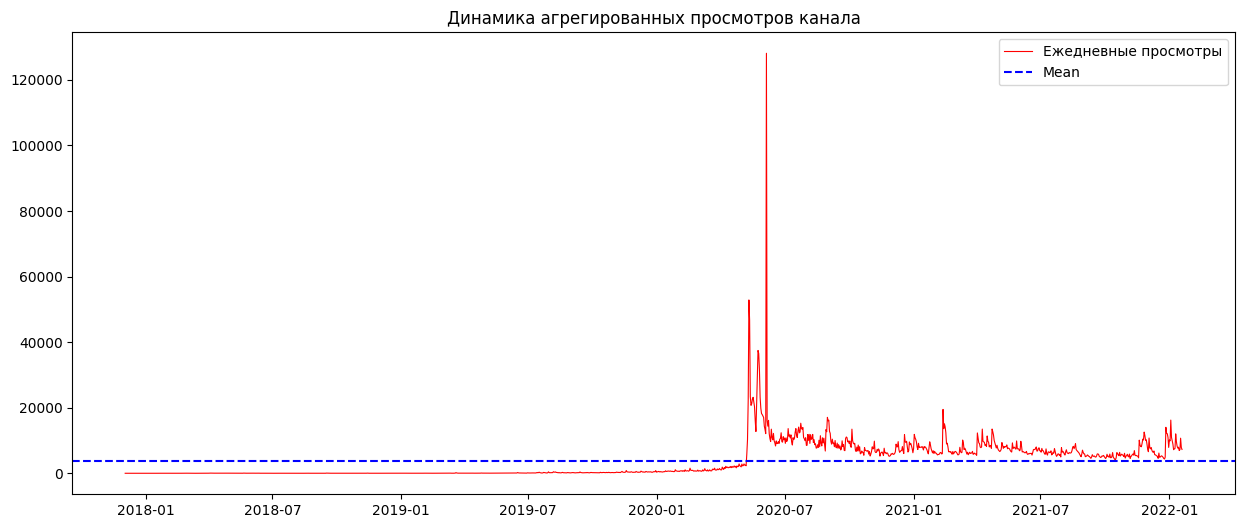

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(df_agg['Date'], df_agg['Views'], color=COLOR, label='Ежедневные просмотры', linewidth=0.8)
plt.axhline(df_agg['Views'].mean(), color='blue', linestyle='--', label='Mean')
plt.title('Динамика агрегированных просмотров канала')
plt.legend()
plt.show()

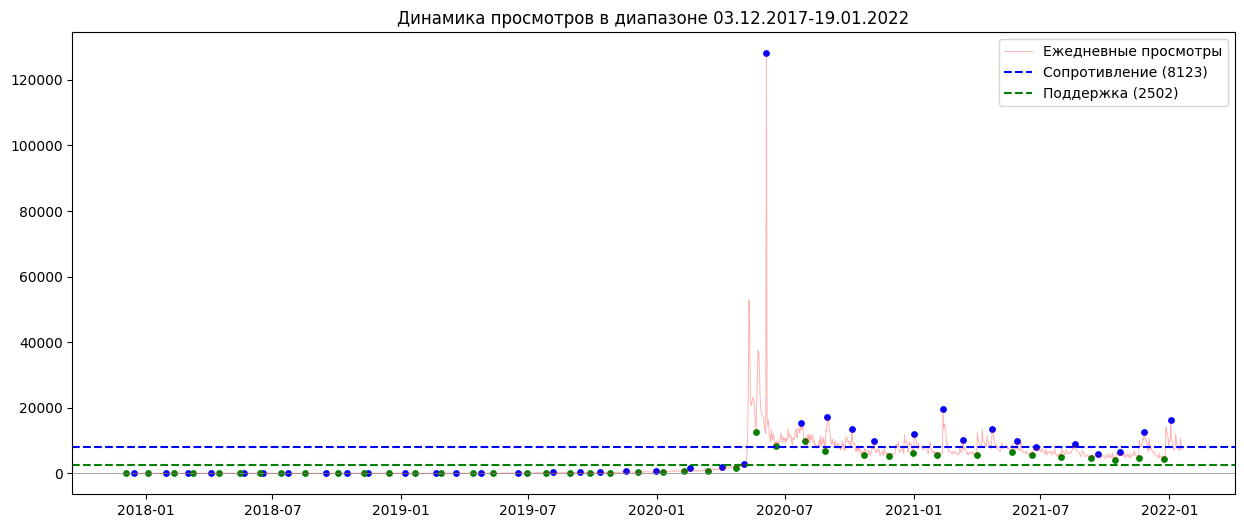

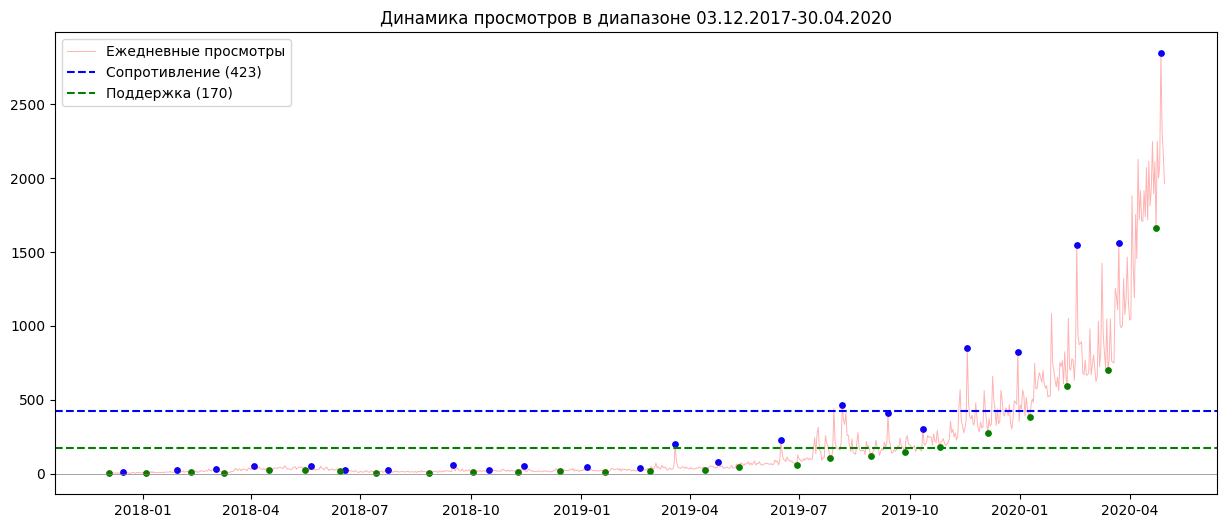

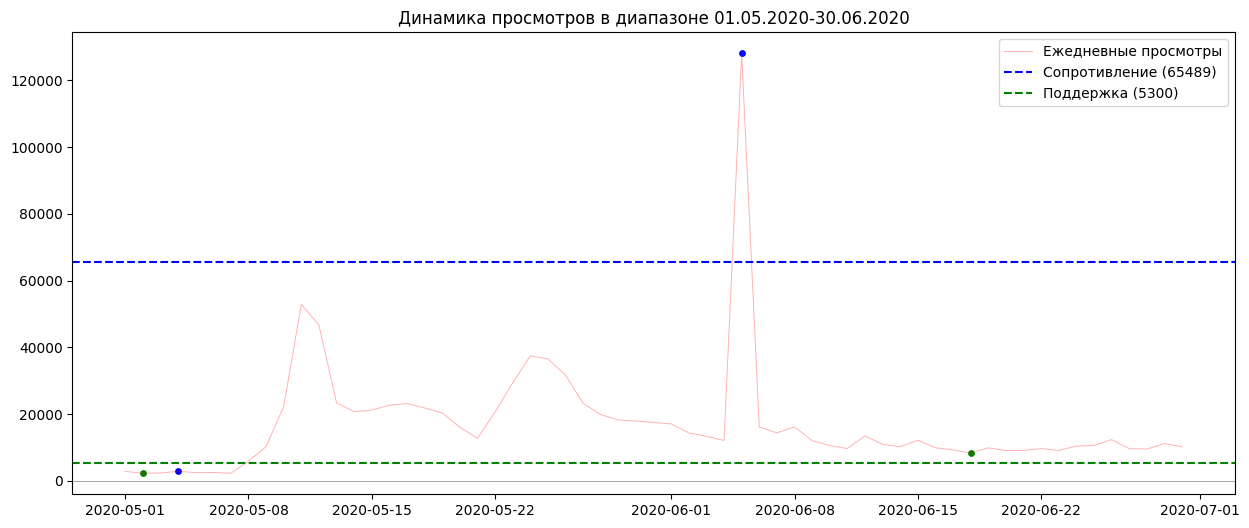

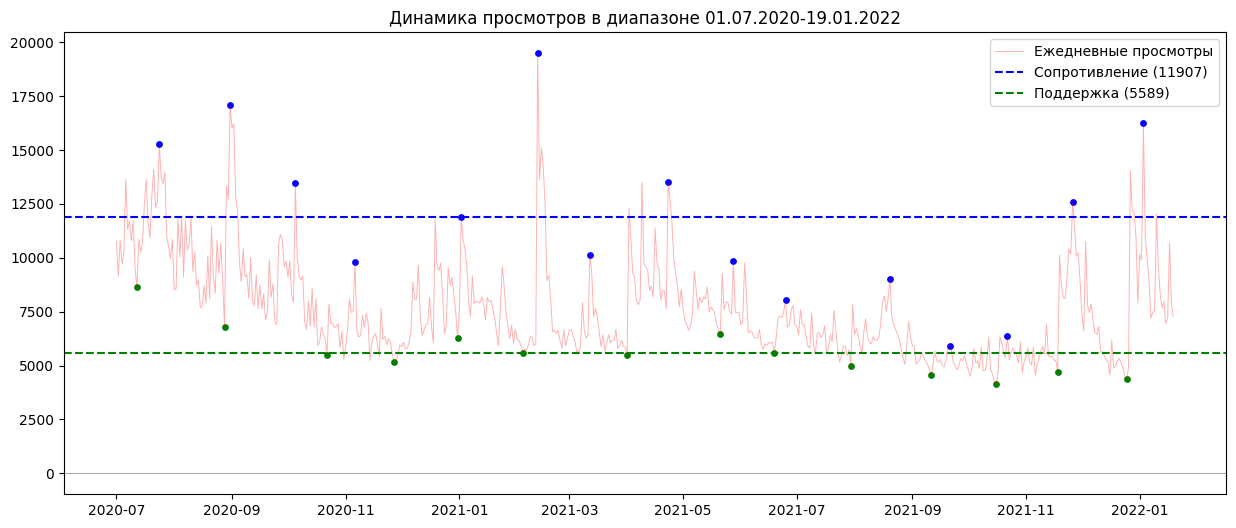

In [7]:
def analyze_range(data):
    peaks, _ = find_peaks(data['Views'], distance=28)
    troughs, _ = find_peaks(-data['Views'], distance=28)

    resistance_level = data.iloc[peaks]['Views'].mean()
    support_level = data.iloc[troughs]['Views'].mean()

    plt.figure(figsize=(15, 6))
    plt.plot(data['Date'], data['Views'], label='Ежедневные просмотры', color=COLOR, alpha=0.3, linewidth=0.7)

    plt.axhline(y=resistance_level, color='blue', linestyle='--', label=f'Сопротивление ({resistance_level:.0f})')
    plt.axhline(y=support_level, color='green', linestyle='--', label=f'Поддержка ({support_level:.0f})')

    plt.scatter(data.iloc[peaks]['Date'], data.iloc[peaks]['Views'], color='blue', s=15)
    plt.scatter(data.iloc[troughs]['Date'], data.iloc[troughs]['Views'], color='green', s=15)

    date_first = data['Date'].min()
    date_last = data['Date'].max()
    plt.title(f'Динамика просмотров в диапазоне {date_first.strftime("%d.%m.%Y")}-{date_last.strftime("%d.%m.%Y")}')
    plt.legend()
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.show()

analyze_range(df_agg)
spike_start = '2020-05-01'
spike_end = '2020-07-01'
analyze_range(df_agg[df_agg['Date'] < spike_start])
analyze_range(df_agg[(df_agg['Date'] >= spike_start) & (df_agg['Date'] < spike_end)])
analyze_range(df_agg[df_agg['Date'] >= spike_end])

## 2. Выявление классических трендов на основе интенсивного и ограниченного роста

In [8]:
video_stats = df.groupby('External Video ID').agg(
    Total_Views=('Views', 'sum'),
    Max_Daily_Views=('Views', 'max'),
    Recent_Views=('Views', lambda x: x.tail(30).sum()),
    Peak_Day=('Views', lambda x: x.argmax()),
    Lifespan=('Date', lambda x: (x.max() - x.min()).days)
)

# High total views but low recent activity relative to peak
limited_id = video_stats[video_stats['Recent_Views'] < (video_stats['Total_Views'] * 0.05)].idxmax()['Total_Views']
s_id = video_stats[(video_stats['Peak_Day'] > 20) & (video_stats['Peak_Day'] < 60)].idxmax()['Total_Views']

# High recent activity compared to total
long_growth = video_stats[video_stats['Lifespan'] > 60]
intensive_id = (long_growth['Recent_Views'] / long_growth['Total_Views']).idxmax()

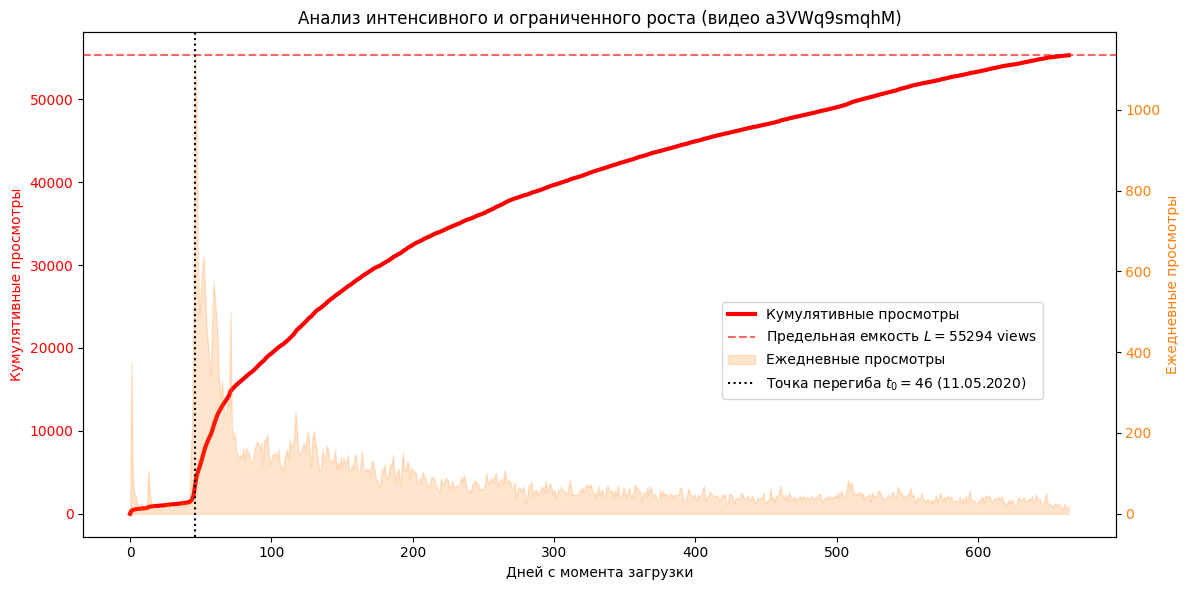

Параметры логистической модели: L=51332, k=0.0108, t0=167.68
Коэффициент детерминации R^2: 0.9590


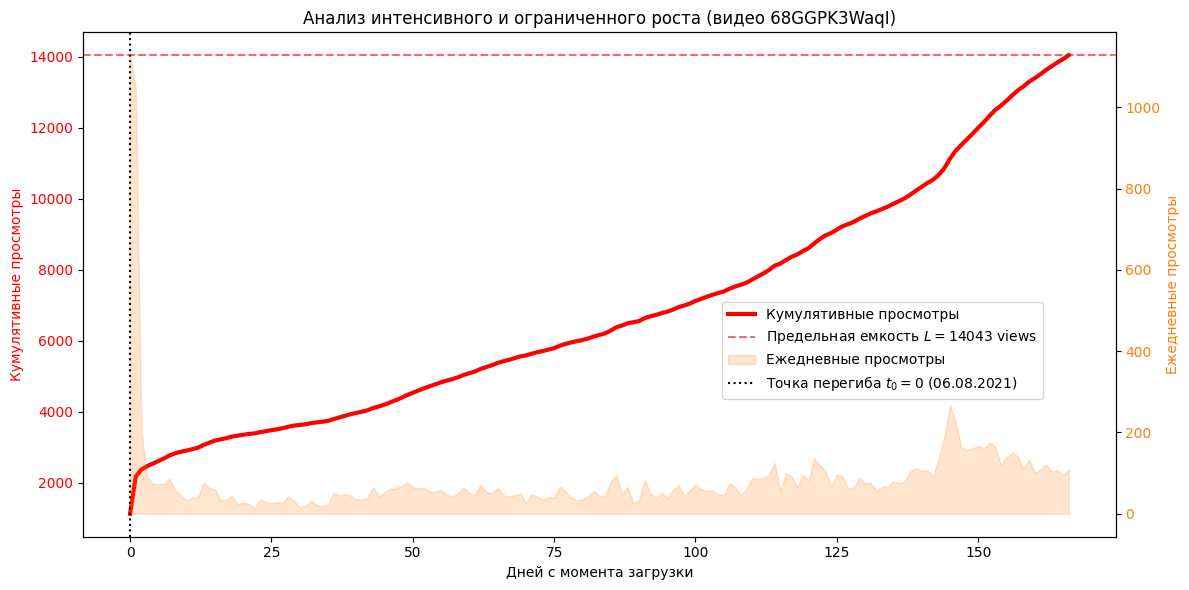

Параметры степенной модели: a=166.68, b=0.8384
Коэффициент детерминации R^2: 0.9201


In [9]:
def analyze_growth(vid_id, model):
    vid_data = df[df['External Video ID'] == vid_id].copy().sort_values('Date')
    vid_data['t'] = range(len(vid_data))
    vid_data['t'] = range(len(vid_data))
    vid_data['Cumulative Views'] = vid_data['Views'].cumsum()

    # Carrying Capacity (L)
    L = vid_data['Cumulative Views'].max()

    # Inflection Point (t0)
    t0 = vid_data.loc[vid_data['Views'].idxmax(), 't']
    date0 = vid_data.loc[vid_data['Views'].idxmax(), 'Date']

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Cumulative Views (The S-Curve)
    ax1.set_xlabel('Дней с момента загрузки')
    ax1.set_ylabel('Кумулятивные просмотры', color=COLOR)
    ax1.plot(vid_data['t'], vid_data['Cumulative Views'], color=COLOR, linewidth=3, label='Кумулятивные просмотры')
    ax1.tick_params(axis='y', labelcolor=COLOR)
    ax1.axhline(y=L, color=COLOR, linestyle='--', alpha=0.6, label=f'Предельная емкость $L={L:.0f}$ views')

    # Daily Views (The Intensive Spike)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Ежедневные просмотры', color='tab:orange')
    ax2.fill_between(vid_data['t'], vid_data['Views'], color='tab:orange', alpha=0.2, label='Ежедневные просмотры')
    ax2.axvline(x=t0, color='black', linestyle=':', label=f'Точка перегиба $t_0={t0}$ ({date0.strftime("%d.%m.%Y")})')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    plt.title(f'Анализ интенсивного и ограниченного роста (видео {vid_id})')
    fig.legend(loc='upper left', bbox_to_anchor=(0.6, 0.5))
    fig.tight_layout()
    plt.show()

    def logistic_model(t, L, k, t0):
        return L / (1 + np.exp(-k * (t - t0)))

    def exponential_model(t, a, b):
        return a * np.exp(b * t)
    
    def power_model(t, a, b):
        return a * np.power(t, b)


    if model == "logistic":
        x_data = vid_data['t'].values
        y_data = vid_data['Cumulative Views'].values

        popt, _ = curve_fit(logistic_model, x_data, y_data, p0=[max(y_data), 0.1, np.median(x_data)])
        L_opt, k_opt, t0_opt = popt

        y_pred = logistic_model(x_data, L_opt, k_opt, t0_opt)
        r_squared = r2_score(y_data, y_pred)

        print(f"Параметры логистической модели: L={L_opt:.0f}, k={k_opt:.4f}, t0={t0_opt:.2f}")
        print(f"Коэффициент детерминации R^2: {r_squared:.4f}")
    
    elif model == "exponential":
        x_data = np.arange(len(vid_data))
        y_data = vid_data['Cumulative Views'].values

        popt, _ = curve_fit(exponential_model, x_data, y_data, p0=[1, 0.5])
        a_opt, b_opt = popt

        y_pred = exponential_model(x_data, a_opt, b_opt)
        r_squared = r2_score(y_data, y_pred)

        print(f"Параметры экспоненциальной модели: a={a_opt:.2f}, b={b_opt:.4f}")
        print(f"Коэффициент детерминации R^2: {r_squared:.4f}")

    elif model == "power":
        x_data = np.arange(1, len(vid_data) + 1) 
        y_data = vid_data['Cumulative Views'].values

        popt, _ = curve_fit(power_model, x_data, y_data, p0=[1, 1.5])
        a_p, b_p = popt

        y_pred_p = power_model(x_data, a_p, b_p)
        r2_p = r2_score(y_data, y_pred_p)

        print(f"Параметры степенной модели: a={a_p:.2f}, b={b_p:.4f}")
        print(f"Коэффициент детерминации R^2: {r2_p:.4f}")

analyze_growth(s_id, "logistic")
analyze_growth(intensive_id, "power")

## 3. Выявление колебаний на основе теории пропорций 

Средний интервал: 7.16 дней
Медианный интервал: 7.0 дней


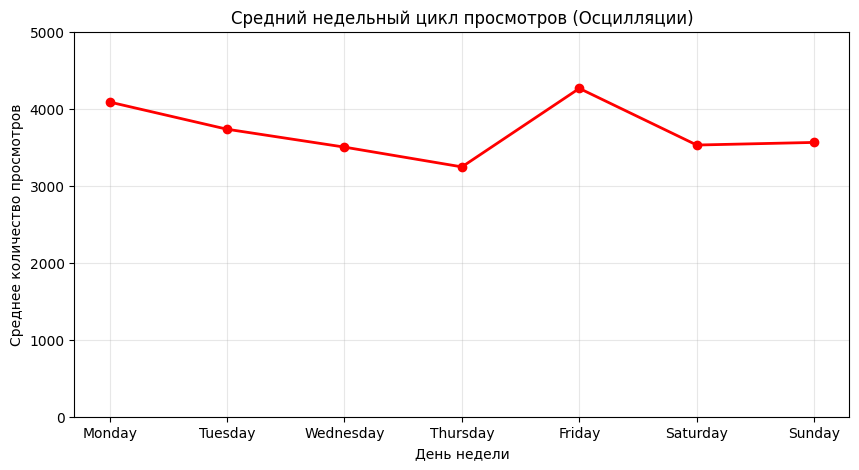

In [10]:
df_agg['Day of Week'] = df_agg['Date'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_profile = df_agg.groupby('Day of Week')['Views'].mean().reindex(weekday_order)

recent_data = df_agg.tail(365)
peaks, _ = find_peaks(recent_data['Views'], distance=5)
intervals = np.diff(peaks)

print(f"Средний интервал: {intervals.mean():.2f} дней")
print(f"Медианный интервал: {np.median(intervals)} дней")

plt.figure(figsize=(10, 5))
weekly_profile.plot(kind='line', marker='o', color=COLOR, linewidth=2)
plt.title('Средний недельный цикл просмотров (Осцилляции)')
plt.xlabel('День недели')
plt.ylabel('Среднее количество просмотров')
plt.grid(True, alpha=0.3)
plt.ylim(0, 5000)
plt.show()

In [11]:
v_fri = weekly_profile['Friday']
v_mon = weekly_profile['Monday']
v_thu = weekly_profile['Thursday']
v_weekend = (weekly_profile['Saturday'] + weekly_profile['Sunday']) / 2

proportions = [
    ["Пик (Пятница) / Минимум (Четверг)", "Views_Fri / Views_Thu", v_fri / v_thu],
    ["Пик (Понедельник) / Минимум (Четверг)", "Views_Mon / Views_Thu", v_mon / v_thu],
    ["Выходные / Минимум (Четверг)", "Views_Avg(Sat, Sun) / Views_Thu", v_weekend / v_thu]
]

proportions = pd.DataFrame(proportions, columns=['Отношение показателей', 'Формула (K)', 'Значение (K)'])
proportions

,Отношение показателей,Формула (K),Значение (K)
0,Пик (Пятница) / Минимум (Четверг),Views_Fri / Views_Thu,1.314184
1,Пик (Понедельник) / Минимум (Четверг),Views_Mon / Views_Thu,1.259538
2,Выходные / Минимум (Четверг),"Views_Avg(Sat, Sun) / Views_Thu",1.092722


## 4. Выявление трендов через скользящее окно и построение математических уравнений

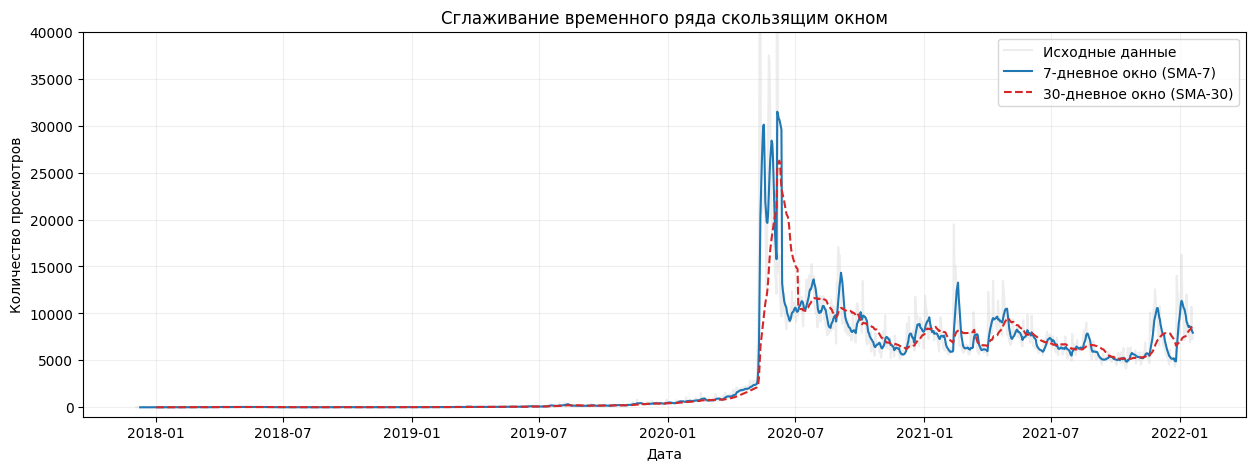

In [16]:
# Simple Moving Average
df_agg['SMA_7'] = df_agg['Views'].rolling(window=7).mean()
df_agg['SMA_30'] = df_agg['Views'].rolling(window=30).mean()

plt.figure(figsize=(15, 5))
plt.plot(df_agg['Date'], df_agg['Views'], color='lightgrey', alpha=0.4, label='Исходные данные')
plt.plot(df_agg['Date'], df_agg['SMA_7'], color='tab:blue', label='7-дневное окно (SMA-7)')
plt.plot(df_agg['Date'], df_agg['SMA_30'], color='tab:red', linestyle='--', label='30-дневное окно (SMA-30)')
plt.title('Сглаживание временного ряда скользящим окном')
plt.xlabel('Дата')
plt.ylabel('Количество просмотров')
plt.legend()
plt.grid(True, alpha=0.2)
plt.ylim(-1000, 40000) 
plt.show()


In [276]:
def analyze_windows(data_slice):
    date_first = data_slice['Date'].min().strftime("%d.%m.%Y")
    date_last = data_slice['Date'].max().strftime("%d.%m.%Y")
    
    y = data_slice['SMA_7'].values
    t = np.arange(len(y)).reshape(-1, 1)
    model = LinearRegression().fit(t, y)
    a, b = model.coef_[0], model.intercept_
    r2 = model.score(t, y)
    
    return {
        "Период": f"{date_first}-{date_last}",
        "Угловой коэффициент (a)": round(a, 2),
        "Свободный член (b)": round(b, 2),
        "Уравнение": f"y = {a:.2f}t + {b:.2f}",
        "R^2": round(r2, 4)
    }

trends = []
trends.append(analyze_windows(df_agg[(df_agg['Date'] >= '2019-01-01') & (df_agg['Date'] < '2019-02-01')].dropna()))
# trends.append(analyze_windows(df_agg[(df_agg['Date'] >= '2019-09-01') & (df_agg['Date'] < '2019-10-01')].dropna()))
trends.append(analyze_windows(df_agg[(df_agg['Date'] >= '2020-06-01') & (df_agg['Date'] < '2020-07-01')].dropna()))
# trends.append(analyze_windows(df_agg[(df_agg['Date'] >= '2020-09-01') & (df_agg['Date'] < '2020-10-01')].dropna()))
trends.append(analyze_windows(df_agg.tail(30).dropna()))

df_trends = pd.DataFrame(trends)
df_trends

,Период,Угловой коэффициент (a),Свободный член (b),Уравнение,R^2
0,01.01.2019-31.01.2019,-0.07,23.83,y = -0.07t + 23.83,0.0302
1,01.06.2020-30.06.2020,-680.83,26056.68,y = -680.83t + 26056.68,0.4939
2,21.12.2021-19.01.2022,119.97,6642.99,y = 119.97t + 6642.99,0.2626
